# 08 ROC-AUC Analysis

Notebook นี้วิเคราะห์ ROC-AUC ของโมเดลหลัก โดยเน้น all-features experiment และเปรียบเทียบ probability behavior ของโมเดลที่สำคัญ

In [2]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 1337
DATA_PATH = Path('data/t2_transformed/merged_v1.csv')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, accuracy_score, f1_score, precision_score, recall_score
import lightgbm as lgb
from catboost import CatBoostClassifier


## 1. Load All-Features Data

ใช้ feature engineering เดียวกับ notebook 05 เพื่อให้ผล ROC อ้างอิงกับ experiment หลักได้

In [3]:

def load_all_features(data_path=DATA_PATH):
    df = pd.read_csv(data_path)
    df = df.drop(columns=[c for c in ['MatchFk', 'Patch'] if c in df.columns], errors='ignore')
    df = df[df['BlueWin'] != df['RedWin']].reset_index(drop=True)
    df = df.drop(columns=['RedWin'], errors='ignore')
    df['BlueWin'] = df['BlueWin'].astype(int)

    lane_cols = [f'Lane_P{p}' for p in range(1, 11)]
    for c in lane_cols:
        if c in df.columns:
            df[c] = df[c].replace('NONE', 'JUNGLE')

    blue_champ_cols = [f'ChampionFk_P{p}' for p in range(1, 6) if f'ChampionFk_P{p}' in df.columns]
    red_champ_cols = [f'ChampionFk_P{p}' for p in range(6, 11) if f'ChampionFk_P{p}' in df.columns]
    champion_cols = blue_champ_cols + red_champ_cols

    blue_champs = df[blue_champ_cols].astype('Int64').astype(str)
    red_champs = df[red_champ_cols].astype('Int64').astype(str)
    champion_ids = (
        pd.concat([blue_champs.stack(), red_champs.stack()], axis=0)
        .replace('<NA>', np.nan)
        .dropna()
        .sort_values()
        .unique()
    )

    champion_features = {}
    for champ_id in champion_ids:
        champion_features[f'BlueChamp_{champ_id}'] = blue_champs.eq(champ_id).any(axis=1).astype(int)
        champion_features[f'RedChamp_{champ_id}'] = red_champs.eq(champ_id).any(axis=1).astype(int)

    df = pd.concat(
        [df.drop(columns=champion_cols, errors='ignore'), pd.DataFrame(champion_features, index=df.index)],
        axis=1,
    )

    categorical_id_prefixes = ('PrimaryKeyStone_', 'SummonerSpell1_', 'SummonerSpell2_')
    categorical_id_cols = [c for c in df.columns if c.startswith(categorical_id_prefixes)]
    for c in categorical_id_cols:
        df[c] = df[c].astype('Int64').astype(str)

    ohe_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    df = pd.get_dummies(df, columns=ohe_cols, dummy_na=False)

    blue_players = [f'P{i}' for i in range(1, 6)]
    red_players = [f'P{i}' for i in range(6, 11)]

    for stat in ['TotalGold', 'MinionsKilled', 'kills', 'deaths', 'assists', 'DmgDealt']:
        blue_cols = [f'{stat}_{p}' for p in blue_players]
        red_cols = [f'{stat}_{p}' for p in red_players]
        if all(c in df.columns for c in blue_cols + red_cols):
            df[f'Blue_{stat}_sum'] = df[blue_cols].sum(axis=1)
            df[f'Red_{stat}_sum'] = df[red_cols].sum(axis=1)
            df[f'Blue_{stat}_avg'] = df[blue_cols].mean(axis=1)
            df[f'Red_{stat}_avg'] = df[red_cols].mean(axis=1)
            df[f'Diff_{stat}'] = df[f'Blue_{stat}_sum'] - df[f'Red_{stat}_sum']

    def safe_kda(k, d, a):
        return (k + a) / d.replace(0, 1)

    kda_required = {'Blue_kills_sum', 'Blue_deaths_sum', 'Blue_assists_sum', 'Red_kills_sum', 'Red_deaths_sum', 'Red_assists_sum'}
    if kda_required.issubset(df.columns):
        df['Blue_KDA'] = safe_kda(df['Blue_kills_sum'], df['Blue_deaths_sum'], df['Blue_assists_sum'])
        df['Red_KDA'] = safe_kda(df['Red_kills_sum'], df['Red_deaths_sum'], df['Red_assists_sum'])
        df['Diff_KDA'] = df['Blue_KDA'] - df['Red_KDA']

    for obj in ['BaronKills', 'RiftHeraldKills', 'DragonKills', 'TowerKills']:
        blue_col = f'Blue{obj}'
        red_col = f'Red{obj}'
        if blue_col in df.columns and red_col in df.columns:
            df[f'Diff_{obj}'] = df[blue_col] - df[red_col]

    if 'BlueKills' in df.columns and 'RedKills' in df.columns:
        df['Diff_Kills'] = df['BlueKills'] - df['RedKills']

    for side, players in [('Blue', blue_players), ('Red', red_players)]:
        gold_cols = [f'TotalGold_{p}' for p in players]
        if all(c in df.columns for c in gold_cols):
            df[f'{side}_GoldStd'] = df[gold_cols].std(axis=1)

    X = df.drop(columns=['BlueWin']).replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    y = df['BlueWin'].astype(int)
    return X, y

X_all, y_all = load_all_features()
print(f'Rows: {len(X_all):,} | Features: {X_all.shape[1]:,} | Blue win ratio: {y_all.mean():.4f}')


Rows: 91,394 | Features: 959 | Blue win ratio: 0.5001


## 2. Train/Test Split

ใช้ split เดิม: train 70%, validation 15%, test 15% และ random state `1337`

In [4]:

OUTPUT_DIR = Path('outputs/roc_auc_analysis')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

split_summary = pd.DataFrame([
    {'split': 'train', 'rows': len(y_train), 'blue_win_ratio': y_train.mean()},
    {'split': 'validation', 'rows': len(y_val), 'blue_win_ratio': y_val.mean()},
    {'split': 'test', 'rows': len(y_test), 'blue_win_ratio': y_test.mean()},
])
display(split_summary)
split_summary.to_csv(OUTPUT_DIR / 'split_summary.csv', index=False)


,split,rows,blue_win_ratio
0,train,63975,0.500055
1,validation,13709,0.500036
2,test,13710,0.500073


## 3. Fit Models For ROC Curves

ใช้ cached best params จาก `outputs/all_features/best_params.csv` เมื่อมีอยู่ และบังคับ CPU/`n_jobs=1` เพื่อให้รันเสถียรบน Windows sandbox

In [5]:

INT_PARAMS = {'max_depth', 'min_samples_leaf', 'n_estimators', 'min_child_weight', 'num_leaves', 'min_child_samples', 'depth'}

def clean_cached_param_value(key, value):
    if pd.isna(value) or value == '':
        return None
    if isinstance(value, str):
        value = value.strip()
        if value == '' or value.lower() == 'nan' or value == 'None':
            return None
    if key in INT_PARAMS:
        return int(float(value))
    if isinstance(value, str):
        try:
            return float(value)
        except ValueError:
            return value
    return value

def load_params(path='outputs/all_features/best_params.csv'):
    params_table = pd.read_csv(path, index_col=0)
    params = {}
    for model_name, row in params_table.iterrows():
        cleaned = {}
        for key, value in row.items():
            v = clean_cached_param_value(key, value)
            if v is not None:
                cleaned[key] = v
        params[model_name] = cleaned
    return params

best_params = load_params()
best_params


{'LogisticRegression': {},
 'DecisionTree': {'max_depth': 6, 'min_samples_leaf': 12},
 'RandomForest': {'max_depth': 15,
  'min_samples_leaf': 10,
  'max_features': 'sqrt',
  'n_estimators': 300,
  'max_samples': 0.75},
 'XGBoost': {'max_depth': 3,
  'learning_rate': 0.1400833704670571,
  'subsample': 0.6000482321625022,
  'colsample_bytree': 0.8278283884527579,
  'min_child_weight': 12,
  'reg_lambda': 0.4844607636773928},
 'LightGBM': {'max_depth': 3,
  'learning_rate': 0.1265906586674903,
  'subsample': 0.8027571953745802,
  'colsample_bytree': 0.8246351194425259,
  'reg_lambda': 0.4172804247815935,
  'num_leaves': 73,
  'min_child_samples': 56},
 'CatBoost': {'learning_rate': 0.097374963857763,
  'depth': 4,
  'l2_leaf_reg': 6.666565895134378,
  'random_strength': 0.2262165913040599}}

In [6]:

models = {
    'LogisticRegression': LogisticRegression(C=1.0, solver='lbfgs', penalty='l2', max_iter=500, random_state=42),
    'RandomForest': RandomForestClassifier(**best_params.get('RandomForest', {}), bootstrap=True, random_state=42, n_jobs=1),
    'LightGBM': lgb.LGBMClassifier(**best_params.get('LightGBM', {}), n_estimators=800, random_state=42, n_jobs=1, verbose=-1),
    'CatBoost': CatBoostClassifier(**best_params.get('CatBoost', {}), iterations=800, random_seed=42, verbose=0, early_stopping_rounds=50),
}

roc_rows = []
curve_rows = []
prob_tables = []

for name, model in models.items():
    print(f'Fitting {name}...')
    uses_scaled = name == 'LogisticRegression'
    Xtr = X_train_sc if uses_scaled else X_train.values
    Xv = X_val_sc if uses_scaled else X_val.values
    Xte = X_test_sc if uses_scaled else X_test.values

    if name == 'LightGBM':
        model.fit(Xtr, y_train.values, eval_set=[(Xv, y_val.values)], callbacks=[lgb.early_stopping(50, verbose=False)])
    elif name == 'CatBoost':
        model.fit(Xtr, y_train.values, eval_set=(Xv, y_val.values))
    else:
        model.fit(Xtr, y_train.values)

    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.50).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, prob)
    pr_auc = auc(recall, precision)

    roc_rows.append({
        'Model': name,
        'ROC_AUC': roc_auc_score(y_test, prob),
        'PR_AUC': pr_auc,
        'Accuracy_at_0_50': accuracy_score(y_test, pred),
        'F1_at_0_50': f1_score(y_test, pred),
        'Mean_Prob_Blue': prob.mean(),
        'Std_Prob_Blue': prob.std(),
    })

    curve_rows.append(pd.DataFrame({'Model': name, 'FPR': fpr, 'TPR': tpr, 'Threshold': thresholds}))
    prob_tables.append(pd.DataFrame({'Model': name, 'Actual': y_test.values, 'Prob_Blue': prob, 'Pred_0_50': pred}, index=y_test.index))

roc_summary = pd.DataFrame(roc_rows).sort_values('ROC_AUC', ascending=False)
roc_curve_points = pd.concat(curve_rows, ignore_index=True)
probability_table = pd.concat(prob_tables).reset_index(names='row_index')

roc_summary.to_csv(OUTPUT_DIR / 'roc_auc_summary.csv', index=False)
roc_curve_points.to_csv(OUTPUT_DIR / 'roc_curve_points.csv', index=False)
probability_table.to_csv(OUTPUT_DIR / 'model_probability_table.csv', index=False)
display(roc_summary)


Fitting LogisticRegression...
Fitting RandomForest...
Fitting LightGBM...
Fitting CatBoost...


,Model,ROC_AUC,PR_AUC,Accuracy_at_0_50,F1_at_0_50,Mean_Prob_Blue,Std_Prob_Blue
3,CatBoost,0.799317,0.810112,0.717724,0.714686,0.500544,0.253624
2,LightGBM,0.798038,0.808231,0.715755,0.712759,0.500249,0.255590
0,LogisticRegression,0.797066,0.804589,0.717433,0.715691,0.500497,0.265205
1,RandomForest,0.780712,0.790588,0.702334,0.698129,0.500862,0.218987


## 4. ROC Curve Comparison

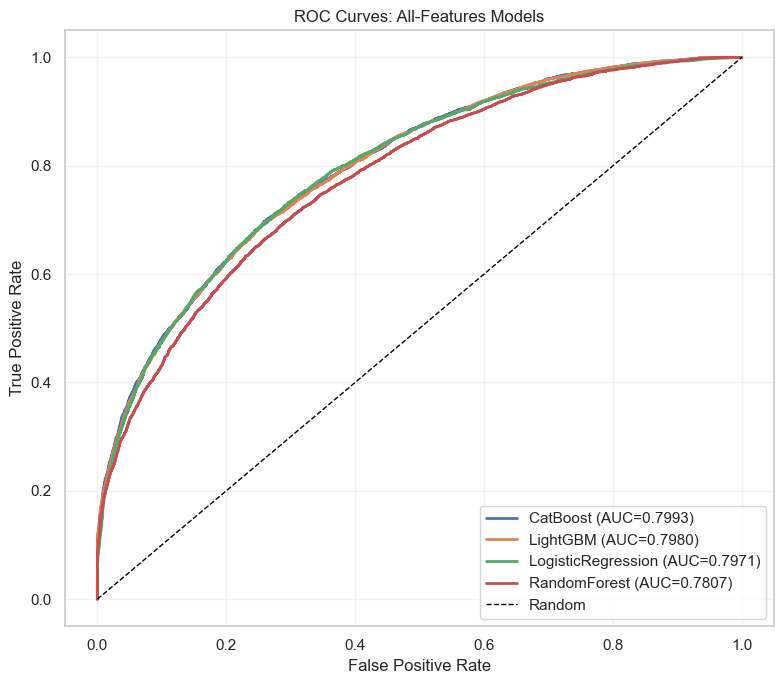

In [7]:

plt.figure(figsize=(8, 7))
for model_name in roc_summary['Model']:
    data = roc_curve_points[roc_curve_points['Model'] == model_name]
    auc_value = roc_summary.loc[roc_summary['Model'] == model_name, 'ROC_AUC'].iloc[0]
    plt.plot(data['FPR'], data['TPR'], linewidth=2, label=f'{model_name} (AUC={auc_value:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All-Features Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_all_features.png', dpi=160, bbox_inches='tight')
plt.show()


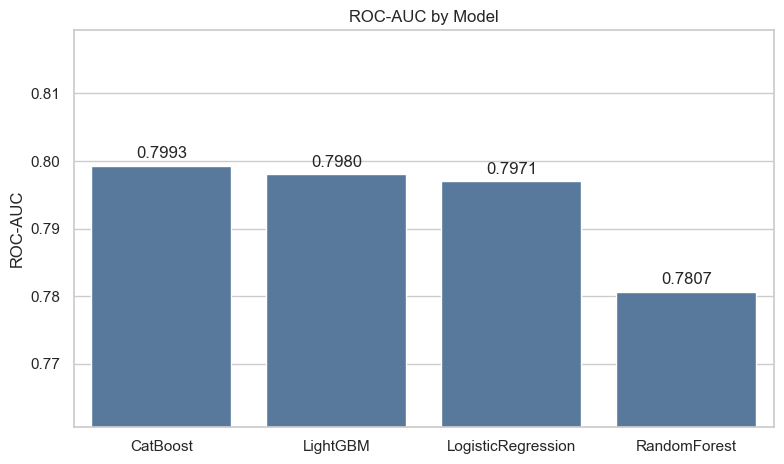

In [8]:

plt.figure(figsize=(8, 4.8))
ax = sns.barplot(data=roc_summary, x='Model', y='ROC_AUC', color='#4C78A8')
ax.bar_label(ax.containers[0], fmt='%.4f', padding=3)
ax.set_ylim(max(0.74, roc_summary['ROC_AUC'].min() - 0.02), min(1.0, roc_summary['ROC_AUC'].max() + 0.02))
ax.set_title('ROC-AUC by Model')
ax.set_xlabel('')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_auc_barplot.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Probability Distribution

ดูว่าโมเดลแยก probability ของ Blue win กับ Red win ได้ชัดแค่ไหน

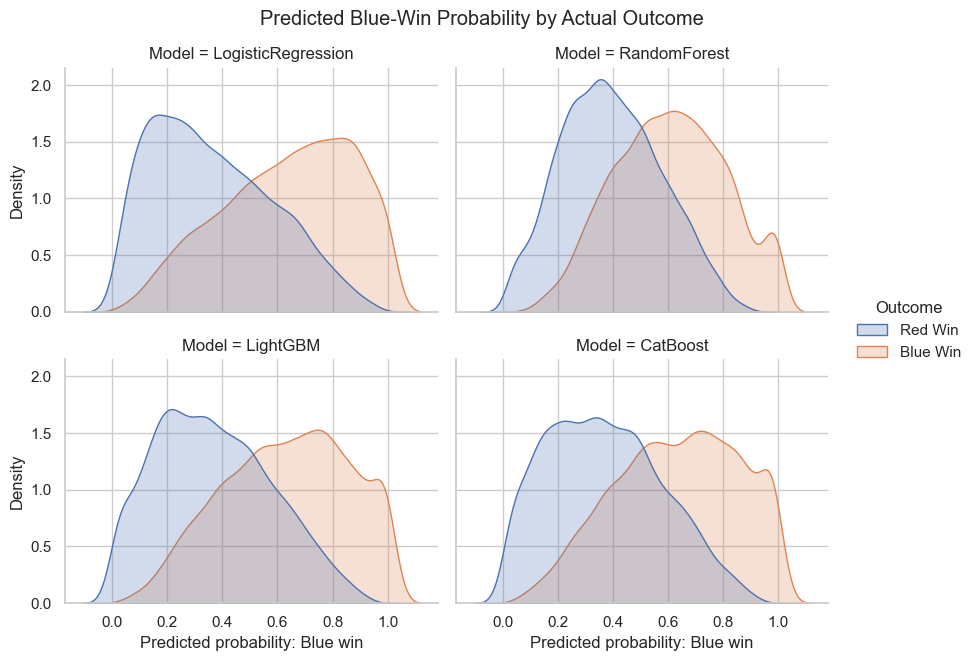

In [9]:

plot_probs = probability_table.copy()
plot_probs['Outcome'] = plot_probs['Actual'].map({0: 'Red Win', 1: 'Blue Win'})

g = sns.displot(
    data=plot_probs,
    x='Prob_Blue',
    hue='Outcome',
    col='Model',
    kind='kde',
    fill=True,
    common_norm=False,
    col_wrap=2,
    height=3.2,
    aspect=1.35,
)
g.fig.suptitle('Predicted Blue-Win Probability by Actual Outcome', y=1.03)
g.set_axis_labels('Predicted probability: Blue win', 'Density')
plt.savefig(OUTPUT_DIR / 'probability_distribution_by_outcome.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Threshold Sweep For Best Model

AUC ไม่ขึ้นกับ threshold แต่การใช้งานจริงต้องเลือก threshold; section นี้ดู trade-off ของ Accuracy/F1/Precision/Recall

,Model,Threshold,Accuracy,F1,Precision,Recall
31,CatBoost,0.36,0.689351,0.736432,0.639579,0.867853
30,CatBoost,0.35,0.685120,0.735688,0.633956,0.876313
32,CatBoost,0.37,0.691758,0.735478,0.644189,0.856914
29,CatBoost,0.34,0.681255,0.735440,0.628648,0.885939
33,CatBoost,0.38,0.695332,0.735315,0.650084,0.846266
28,CatBoost,0.33,0.676659,0.734344,0.623233,0.893670
27,CatBoost,0.32,0.672356,0.733318,0.618342,0.900817
34,CatBoost,0.39,0.695551,0.732539,0.653257,0.833722
35,CatBoost,0.40,0.699125,0.732369,0.659577,0.823221
36,CatBoost,0.41,0.702188,0.732174,0.665276,0.814032


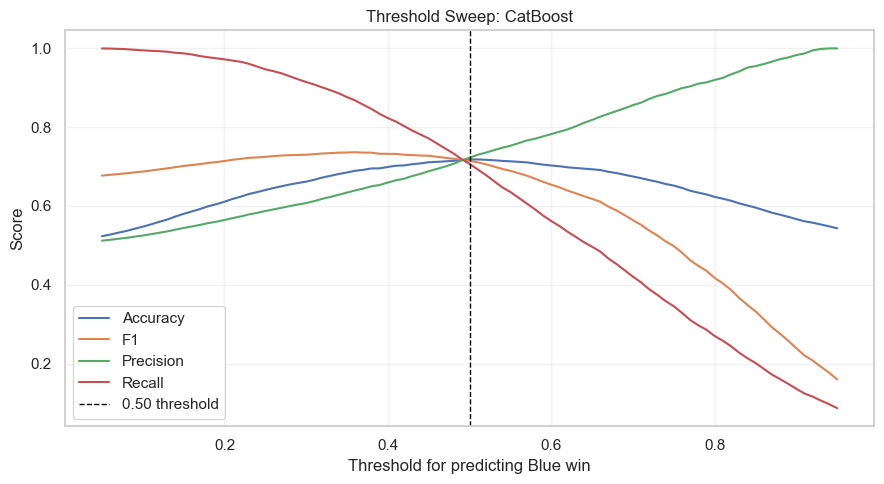

In [10]:

best_model_name = roc_summary.iloc[0]['Model']
best_prob = probability_table[probability_table['Model'] == best_model_name].set_index('row_index').loc[y_test.index, 'Prob_Blue'].to_numpy()

threshold_rows = []
for threshold in np.linspace(0.05, 0.95, 91):
    pred = (best_prob >= threshold).astype(int)
    threshold_rows.append({
        'Model': best_model_name,
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
    })
threshold_sweep = pd.DataFrame(threshold_rows)
threshold_sweep.to_csv(OUTPUT_DIR / 'threshold_sweep_best_model.csv', index=False)

display(threshold_sweep.sort_values('F1', ascending=False).head(10))

plt.figure(figsize=(9, 5))
for metric in ['Accuracy', 'F1', 'Precision', 'Recall']:
    plt.plot(threshold_sweep['Threshold'], threshold_sweep[metric], label=metric)
plt.axvline(0.50, color='black', linestyle='--', linewidth=1, label='0.50 threshold')
plt.xlabel('Threshold for predicting Blue win')
plt.ylabel('Score')
plt.title(f'Threshold Sweep: {best_model_name}')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_sweep_best_model.png', dpi=160, bbox_inches='tight')
plt.show()


## 7. Conclusion

ใช้ `roc_auc_summary.csv`, `roc_curves_all_features.png`, และ `threshold_sweep_best_model.csv` เป็น output หลักของ notebook นี้

In [11]:

conclusion = (
    f"Best ROC-AUC model in this ROC run: {best_model_name} "
    f"with ROC-AUC={roc_summary.iloc[0]['ROC_AUC']:.4f}. "
    f"AUC compares ranking quality across thresholds, while the threshold sweep shows operational trade-offs at specific decision cutoffs."
)
(OUTPUT_DIR / 'roc_auc_conclusion.txt').write_text(conclusion, encoding='utf-8')
print(conclusion)
print(f'Outputs saved to: {OUTPUT_DIR.resolve()}')


Best ROC-AUC model in this ROC run: CatBoost with ROC-AUC=0.7993. AUC compares ranking quality across thresholds, while the threshold sweep shows operational trade-offs at specific decision cutoffs.
Outputs saved to: C:\Users\win25\Desktop\Desktop\work\CPE232 Data models\ProjectModelleing\Predicting-League-of-Legends-Match-Outcomes-Using-10-Minute-Data\outputs\roc_auc_analysis
